<a href="https://colab.research.google.com/github/AliAI11/DeepLens/blob/main/notebooks/01_dataset_exploration_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# installing packages
!pip install -q datasets huggingface_hub transformers torch torchvision pillow tqdm matplotlib pandas numpy

In [ ]:
# imports and seeds
import pandas as pd
import numpy as np
import json
import random
import os
from pathlib import Path
from tqdm import tqdm

from huggingface_hub import snapshot_download
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
np.random.seed(42)

print('imports complete')

imports complete


In [ ]:
# local working directories
os.makedirs('./data', exist_ok=True)
os.makedirs('./models', exist_ok=True)
os.makedirs('./ntire_train', exist_ok=True)

print('local directories ready: ./data, ./models, ./ntire_train')

local directories ready: ./data, ./models, ./ntire_train


In [ ]:
# download just shard_0.zip
print('downloading shard_0.zip from NTIRE training set...')
ntire_dir = snapshot_download(
    repo_id="deepfakesMSU/NTIRE-RobustAIGenDetection-train",
    repo_type="dataset",
    allow_patterns=["shard_0.zip"],
    local_dir="./ntire_train"
)

print(f'\ndownloaded to: {ntire_dir}')

# confirm the zip is there and check size
zip_path = './ntire_train/shard_0.zip'
size_gb = os.path.getsize(zip_path) / 1e9
print(f'shard_0.zip: {size_gb:.2f} GB')

downloading shard_0.zip from NTIRE training set...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]


downloaded to: /content/ntire_train
shard_0.zip: 20.59 GB


In [ ]:
# extracting the zip
import zipfile

zip_path = './ntire_train/shard_0.zip'
extract_dir = './ntire_train'

print('extracting shard_0.zip...')
with zipfile.ZipFile(zip_path, 'r') as z:
    # peek at structure
    members = z.namelist()
    print(f'archive contains {len(members)} entries')
    print(f'first 5: {members[:5]}')
    print(f'last 5:  {members[-5:]}')

    z.extractall(extract_dir)

print('\nextraction complete')

# free disk: delete the zip now that we've extracted
os.remove(zip_path)
print('removed zip file to free disk')

# verify structure
print(f'\ncontents of {extract_dir}:')
for item in sorted(os.listdir(extract_dir)):
    full_path = os.path.join(extract_dir, item)
    if os.path.isdir(full_path):
        print(f'  {item}/')
        for sub in sorted(os.listdir(full_path))[:5]:
            sub_full = os.path.join(full_path, sub)
            if os.path.isdir(sub_full):
                n = len(os.listdir(sub_full))
                print(f'    {sub}/ ({n} files)')
            else:
                print(f'    {sub}')

extracting shard_0.zip...
archive contains 50003 entries
first 5: ['shard_0/', 'shard_0/images/', 'shard_0/images/6a9c9290c894ecffb396.jpg', 'shard_0/images/86e992f14caa87bb193b.jpg', 'shard_0/images/2c29191f83542c8d5814.jpg']
last 5:  ['shard_0/images/b4c2769725e7f55e8047.jpg', 'shard_0/images/f05f6d7743fe80b5105f.jpg', 'shard_0/images/af1dda35d96b954a37de.jpg', 'shard_0/images/7cdea9cfa0abbc1d2967.jpg', 'shard_0/labels.csv']

extraction complete
removed zip file to free disk

contents of ./ntire_train:
  .cache/
    huggingface/ (3 files)
  shard_0/
    images/ (50000 files)
    labels.csv


In [ ]:
# inspecting the file structure
shard_dir = './ntire_train/shard_0'
print(f'contents of {shard_dir}:')
for item in sorted(os.listdir(shard_dir)):
    full_path = os.path.join(shard_dir, item)
    if os.path.isdir(full_path):
        n_files = len(os.listdir(full_path))
        print(f'  {item}/ ({n_files} files)')
    else:
        size_mb = os.path.getsize(full_path) / 1e6
        print(f'  {item} ({size_mb:.2f} MB)')

contents of ./ntire_train/shard_0:
  images/ (50000 files)
  labels.csv (1.64 MB)


In [ ]:
# loading labels
# labels.csv maps image_name -> label (0 = real, 1 = fake)
labels_path = os.path.join(shard_dir, 'labels.csv')
labels_df = pd.read_csv(labels_path, index_col=0)

print(f'loaded {len(labels_df)} labeled images')
print(f'\ncolumns: {labels_df.columns.tolist()}')
print(f'\nfirst 5 rows:')
print(labels_df.head())
print(f'\nlabel dtype: {labels_df["label"].dtype}')

loaded 50000 labeled images

columns: ['image_name', 'label']

first 5 rows:
                 image_name  label
0  ed97447bcc3cea21bfa2.jpg      0
1  8252d6ad09a67674576a.jpg      0
2  01a84d7398e97a047b7c.jpg      1
3  0c6a4e6cca4e9e582cf9.jpg      1
4  99aec474f7ef493820c9.jpg      1

label dtype: int64


In [ ]:
# seeing class balance
# class distribution in shard_0
print('class distribution in shard_0:')
counts = labels_df['label'].value_counts().sort_index()
print(counts)
print(f'\ntotal: {len(labels_df)}')
print(f'real (0): {counts.get(0, 0)}')
print(f'fake (1): {counts.get(1, 0)}')
print(f'fake fraction: {counts.get(1, 0) / len(labels_df):.3f}')

# verify all referenced images actually exist on disk
images_dir = os.path.join(shard_dir, 'images')
existing = set(os.listdir(images_dir))
missing = [name for name in labels_df['image_name'].head(100) if name not in existing]
print(f'\nspot-check: {len(missing)}/100 sampled labels reference missing images')

class distribution in shard_0:
label
0    17982
1    32018
Name: count, dtype: int64

total: 50000
real (0): 17982
fake (1): 32018
fake fraction: 0.640

spot-check: 0/100 sampled labels reference missing images


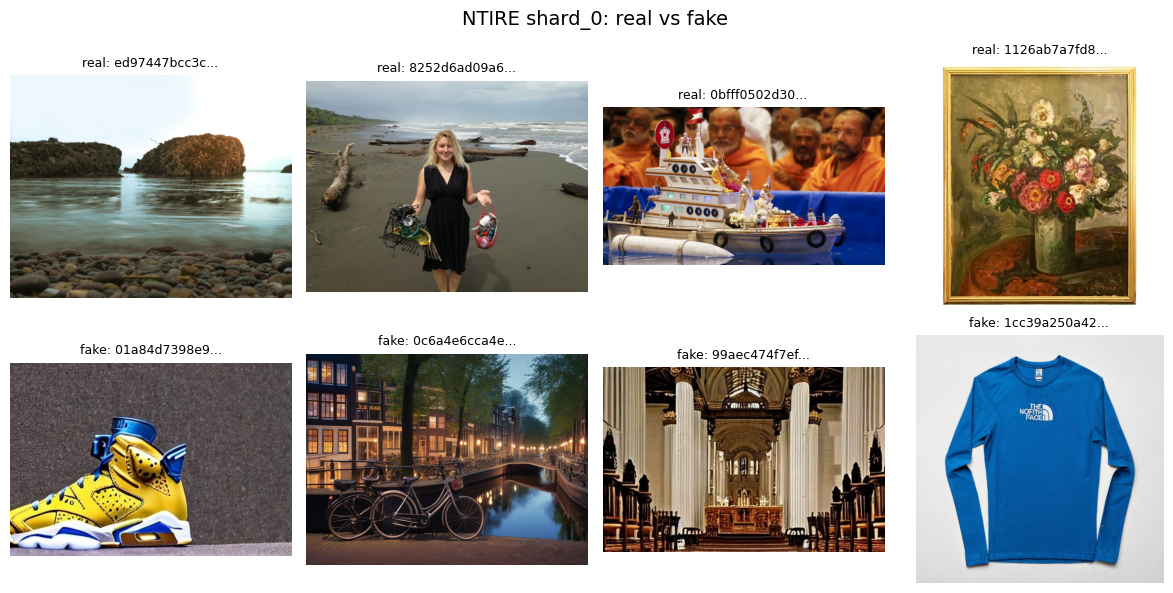

In [ ]:
def show_samples(labels_df, images_dir, n=4, title='samples'):
    """show n real and n fake samples side by side"""
    real_rows = labels_df[labels_df['label'] == 0].head(n)
    fake_rows = labels_df[labels_df['label'] == 1].head(n)

    fig, axes = plt.subplots(2, n, figsize=(n*3, 6))
    fig.suptitle(title, fontsize=14)

    for i, (_, row) in enumerate(real_rows.iterrows()):
        img = Image.open(os.path.join(images_dir, row['image_name']))
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'real: {row["image_name"][:12]}...', fontsize=9)
        axes[0, i].axis('off')

    for i, (_, row) in enumerate(fake_rows.iterrows()):
        img = Image.open(os.path.join(images_dir, row['image_name']))
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'fake: {row["image_name"][:12]}...', fontsize=9)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(labels_df, images_dir, n=4, title='NTIRE shard_0: real vs fake')

In [ ]:
# check image dimensions across a 500-sample subset
print('measuring image dimensions on a 500-sample subset...')

sample_rows = labels_df.sample(min(500, len(labels_df)), random_state=42)
widths, heights, modes = [], [], []

for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc='measuring'):
    img = Image.open(os.path.join(images_dir, row['image_name']))
    widths.append(img.size[0])
    heights.append(img.size[1])
    modes.append(img.mode)

print(f'\nwidth:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}, median={np.median(widths):.0f}')
print(f'height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}, median={np.median(heights):.0f}')
print(f'\nimage modes: {pd.Series(modes).value_counts().to_dict()}')

unique_dims = set(zip(widths, heights))
print(f'\nunique (w, h) combinations in sample: {len(unique_dims)}')
if len(unique_dims) <= 20:
    print(f'dimensions: {sorted(unique_dims)}')
else:
    print(f'(images vary in size, will resize to 224x224 for ViT)')

measuring image dimensions on a 500-sample subset...


measuring: 100%|██████████| 500/500 [00:00<00:00, 6158.64it/s]


width:  min=288, max=4032, mean=1181, median=1024
height: min=288, max=4032, mean=1144, median=1024

image modes: {'RGB': 500}

unique (w, h) combinations in sample: 227
(images vary in size, will resize to 224x224 for ViT)


In [ ]:
# balanced subsample for fine-tuning ViT
TARGET_SIZE = 25000
PER_CLASS = TARGET_SIZE // 2

print(f'building balanced subsample: {TARGET_SIZE} images ({PER_CLASS} per class)')

real_df = labels_df[labels_df['label'] == 0]
fake_df = labels_df[labels_df['label'] == 1]

print(f'\navailable in shard_0: {len(real_df)} real, {len(fake_df)} fake')

n_real = min(PER_CLASS, len(real_df))
n_fake = min(PER_CLASS, len(fake_df))

real_sample = real_df.sample(n=n_real, random_state=42)
fake_sample = fake_df.sample(n=n_fake, random_state=42)

selected_df = pd.concat([real_sample, fake_sample], ignore_index=True)
selected_df = selected_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nselected: {n_real} real + {n_fake} fake = {len(selected_df)} total')

building balanced subsample: 25000 images (12500 per class)

available in shard_0: 17982 real, 32018 fake

selected: 12500 real + 12500 fake = 25000 total


In [ ]:
# split into 80% train, 10% internal val (early stopping), 10% test (final eval)
print('splitting 80/10/10 into train, val, test...')

n_total = len(selected_df)
n_train = int(n_total * 0.80)
n_val = int(n_total * 0.10)

train_df = selected_df.iloc[:n_train].copy()
val_df = selected_df.iloc[n_train:n_train + n_val].copy()
test_df = selected_df.iloc[n_train + n_val:].copy()

train_df['split'] = 'train'
val_df['split'] = 'val_internal'
test_df['split'] = 'test'

print(f'\ntrain: {len(train_df)} images ({sum(train_df["label"])} fake / {len(train_df) - sum(train_df["label"])} real)')
print(f'val:   {len(val_df)} images ({sum(val_df["label"])} fake / {len(val_df) - sum(val_df["label"])} real)')
print(f'test:  {len(test_df)} images ({sum(test_df["label"])} fake / {len(test_df) - sum(test_df["label"])} real)')

splitting 80/10/10 into train, val, test...

train: 20000 images (9962 fake / 10038 real)
val:   2500 images (1285 fake / 1215 real)
test:  2500 images (1253 fake / 1247 real)


In [ ]:
# save split metadata so notebook 02 can re-create the splits
splits_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
splits_df['shard_name'] = 'shard_0'

# add full path column for convenience downstream
splits_df['rel_path'] = splits_df.apply(
    lambda r: os.path.join(r['shard_name'], 'images', r['image_name']), axis=1
)

splits_df.to_csv('./data/splits.csv', index=False)

print(f'saved {len(splits_df)} rows to ./data/splits.csv')
print(f'\nsample rows:')
print(splits_df.head())
print(f'\nsplit counts:')
print(splits_df['split'].value_counts())

saved 25000 rows to ./data/splits.csv

sample rows:
                 image_name  label  split shard_name  \
0  ae21daa66c731232268d.jpg      0  train    shard_0   
1  167b9cb3a7722c858b3c.jpg      1  train    shard_0   
2  ae4b2b3e81826b1674c7.jpg      0  train    shard_0   
3  345d69d181989be74695.jpg      1  train    shard_0   
4  fb2ae30e2fb827a21756.jpg      1  train    shard_0   

                                  rel_path  
0  shard_0/images/ae21daa66c731232268d.jpg  
1  shard_0/images/167b9cb3a7722c858b3c.jpg  
2  shard_0/images/ae4b2b3e81826b1674c7.jpg  
3  shard_0/images/345d69d181989be74695.jpg  
4  shard_0/images/fb2ae30e2fb827a21756.jpg  

split counts:
split
train           20000
val_internal     2500
test             2500
Name: count, dtype: int64


In [ ]:
# save dataset config so notebook 02 doesn't need to re-figure structure
ds_config = {
    'source_dataset': 'deepfakesMSU/NTIRE-RobustAIGenDetection-train',
    'shards_used': ['shard_0'],
    'image_size_target': 224,
    'subsample_size': TARGET_SIZE,
    'split_ratios': {'train': 0.80, 'val_internal': 0.10, 'test': 0.10},
    'label_map': {0: 'real', 1: 'fake'},
    'note': 'official val set has no labels; we use our test split for final eval'
}

with open('./data/dataset_config.json', 'w') as f:
    json.dump(ds_config, f, indent=2)

print(f'saved dataset config:')
print(json.dumps(ds_config, indent=2))

saved dataset config:
{
  "source_dataset": "deepfakesMSU/NTIRE-RobustAIGenDetection-train",
  "shards_used": [
    "shard_0"
  ],
  "image_size_target": 224,
  "subsample_size": 25000,
  "split_ratios": {
    "train": 0.8,
    "val_internal": 0.1,
    "test": 0.1
  },
  "label_map": {
    "0": "real",
    "1": "fake"
  },
  "note": "official val set has no labels; we use our test split for final eval"
}


In [ ]:
# download files needed for notebook 02
from google.colab import files

print('downloading artifacts...')
files.download('./data/splits.csv')
files.download('./data/dataset_config.json')

print('\ndownload complete')

downloading artifacts...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


download complete
